# EX.01

In [ ]:
!pip install opencv-python

In [ ]:
# 설치 버전 확인
import cv2 as cv
print(cv.__version__)
print(cv.getBuildInformation())

4.13.0

General configuration for OpenCV 4.13.0 =====================================
  Version control:               4.13.0-1-gb4c5ec4042-dirty

  Platform:
    Timestamp:                   2026-02-03T07:17:59Z
    Host:                        Linux 6.8.0-1044-azure x86_64
    CMake:                       4.2.1
    CMake generator:             Unix Makefiles
    CMake build tool:            /bin/gmake
    Configuration:               Release
    Algorithm Hint:              ALGO_HINT_ACCURATE

  CPU/HW features:
    Baseline:                    SSE SSE2 SSE3
      requested:                 SSE3
    Dispatched code generation:  SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX
      SSE4_1 (17 files):         + SSSE3 SSE4_1
      SSE4_2 (1 files):          + SSSE3 SSE4_1 POPCNT SSE4_2
      AVX (9 files):             + SSSE3 SSE4_1 POPCNT SSE4_2 AVX
      FP16 (0 files):            + SSSE3 SSE4_1 POPCNT SSE4_2 AVX FP16
      AVX2 (37 files):           + SSSE3 SSE4_1 POPCNT SSE4_2 AVX FP16 AVX2 

# 1-1

In [ ]:
# 파일 받기
!wget --content-disposition https://www.dropbox.com/scl/fi/s14uhqgdkmvalefb50r7p/apple.jpg?rlkey=khlkf94j95vdtpmxqsnk0k4ga&dl=0

--2026-03-15 23:18:11--  https://www.dropbox.com/scl/fi/s14uhqgdkmvalefb50r7p/apple.jpg?rlkey=khlkf94j95vdtpmxqsnk0k4ga
Resolving www.dropbox.com (www.dropbox.com)... 162.125.80.18, 2620:100:6030:18::a27d:5012
Connecting to www.dropbox.com (www.dropbox.com)|162.125.80.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd7034674ee82ac1cd20185d98d.dl.dropboxusercontent.com/cd/0/inline/C8vDR6PFypwPV6OZFvgqbSH1ID5hCuXAI7qMenDbDQNoh8vXMwvpdwO-b-dZ3Zk64mMzw_Yv-FA3vqTPMRf8khss-MAT7dTqX8XAkXpCwsTRo6cdy_NLY1qBn1gYKSrdyFQ5_lGDllQkc04hvHHYbeR9/file# [following]
--2026-03-15 23:18:12--  https://ucd7034674ee82ac1cd20185d98d.dl.dropboxusercontent.com/cd/0/inline/C8vDR6PFypwPV6OZFvgqbSH1ID5hCuXAI7qMenDbDQNoh8vXMwvpdwO-b-dZ3Zk64mMzw_Yv-FA3vqTPMRf8khss-MAT7dTqX8XAkXpCwsTRo6cdy_NLY1qBn1gYKSrdyFQ5_lGDllQkc04hvHHYbeR9/file
Resolving ucd7034674ee82ac1cd20185d98d.dl.dropboxusercontent.com (ucd7034674ee82ac1cd20185d98d.dl.dropboxusercontent.com)... 162.125.64.15, 2620:

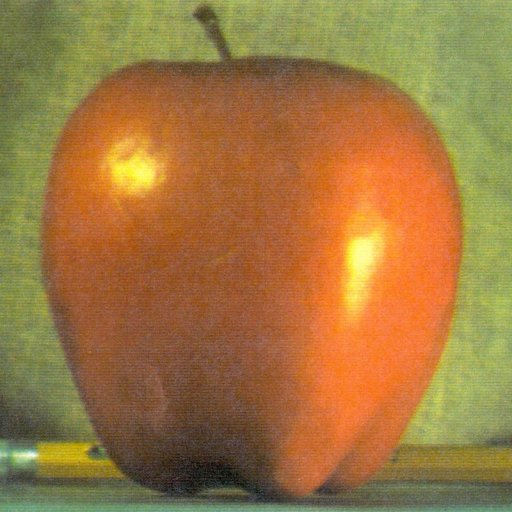

[[[ 91 126 122]
  [ 82 119 115]
  [ 87 124 120]
  ...
  [103 168 153]
  [103 168 153]
  [105 170 155]]

 [[ 87 122 118]
  [ 77 114 110]
  [ 80 117 113]
  ...
  [114 181 166]
  [116 183 168]
  [118 185 170]]

 [[ 82 117 113]
  [ 74 111 107]
  [ 78 115 111]
  ...
  [108 178 161]
  [109 180 163]
  [111 182 165]]

 ...

 [[113 157 116]
  [115 160 117]
  [120 163 120]
  ...
  [109 139  98]
  [109 141 100]
  [111 144 100]]

 [[107 151 112]
  [109 153 112]
  [112 155 112]
  ...
  [112 143  98]
  [111 144  99]
  [111 144  99]]

 [[113 157 118]
  [113 157 116]
  [117 157 116]
  ...
  [125 156 111]
  [120 154 107]
  [118 152 105]]]


In [ ]:
from google.colab.patches import cv2_imshow
# OpenCV에서 이미지를 띄울 때는 cv2.imshow()를 쓰는데, 구글 코랩에서는
# 보안과 브라우저 호환성 문제로 이 함수를 쓰면 에러가 나거나 세션이 죽어서
# 코랩 전용 패치인 cv2_imshow를 사용

image = cv.imread("apple.jpg") # imread - 이미지 파일을 읽어서 컴퓨터가
                               #          이해할 수 있는 숫자 행렬로 변환해줌
cv2_imshow(image)
print(image)

200 300 [ 42  86 150]


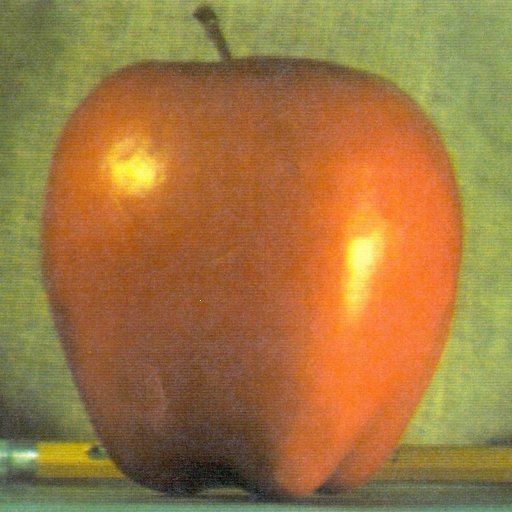

In [ ]:
x, y = 200, 300 # y - 위에서 아래로 몇 번째 줄인지 (Row 행)
                # x - 왼쪽에서 오른쪽으로 몇 번째 칸인지 (column 열)
pixel_value = image[y, x]
print(x, y, pixel_value)

image[y, x] = [255, 255, 255] # BGR 순서 - (255, 255, 255)는 흰색
cv2_imshow(image)

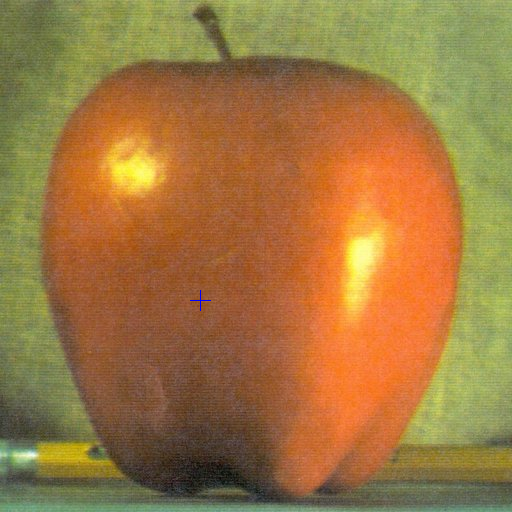

In [ ]:
cv.drawMarker(image, (x, y), (255, 0, 0), 0) # Marker 표시 함수
cv2_imshow(image)

# 1-2

In [ ]:
import cv2 as cv
import numpy as np
inp = cv.imread("apple.jpg")

# 상수 파라메터
FILTER_SIZE = 5
FILTER_SIGMA = 5

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


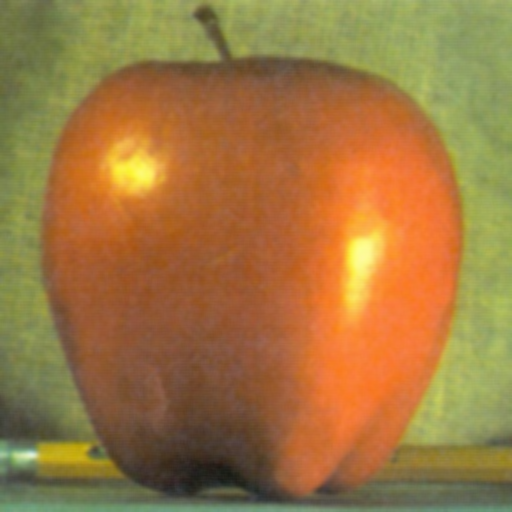

In [ ]:
# Averaging
def filter_averaging( inp ):
    filter = np.ones((FILTER_SIZE,FILTER_SIZE)) / (FILTER_SIZE*FILTER_SIZE)
    print(filter)

    out = cv.filter2D(inp, -1, filter) # 두 번째 패러미터 -1: 데이터 타입 원본과 동일
    return out

out_average  = filter_averaging( inp )
cv2_imshow(out_average)

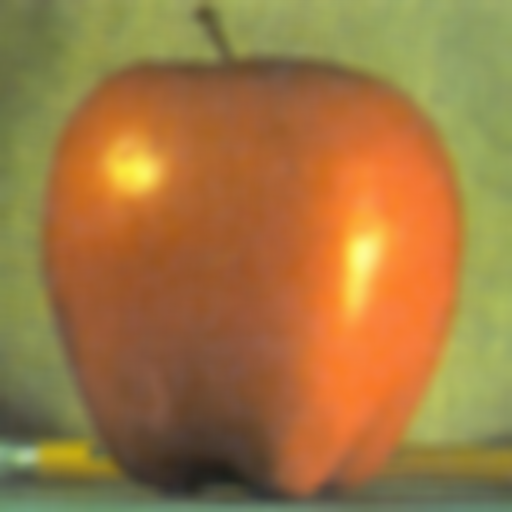

In [ ]:
FILTER_SIZE = 5
FILTER_SIGMA = 5

# Gaussian filter
def filter_gaussian(inp):
    out = cv.GaussianBlur(inp, (FILTER_SIZE, FILTER_SIZE), FILTER_SIGMA)
    return out

# cv.GaussianBlur(src, ksize, sigmaX, sigmaY, borderType)
# inp (src)
# (Filter_SIZE, FILTER_SIZE) (ksize)
# FILTER_SIGMA (sigmaX) - X 방향의 표준 편차
# sigmaY (생략됨) - Y 방향의 표준 편차. 따로 적지 않으면 기본적으로 sigmaX와 같은 값을 사용


out_gaussian  = filter_gaussian( inp )
cv2_imshow(out_gaussian)

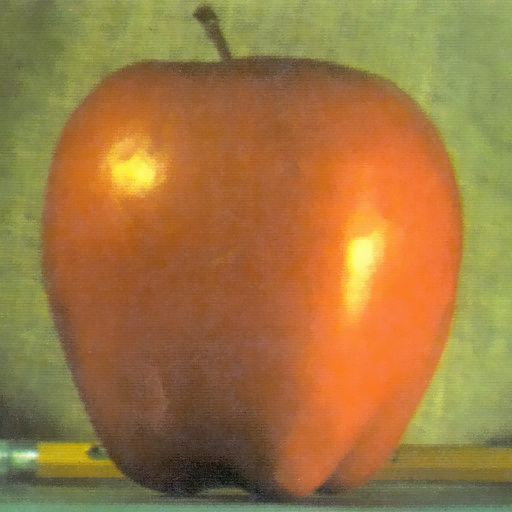

In [ ]:
# Bilateral filter
def filter_bilateral(inp):
    out = cv.bilateralFilter(inp, FILTER_SIZE, FILTER_SIGMA, FILTER_SIGMA)
    return out

out_bilateral  = filter_bilateral( inp )
cv2_imshow(out_bilateral)